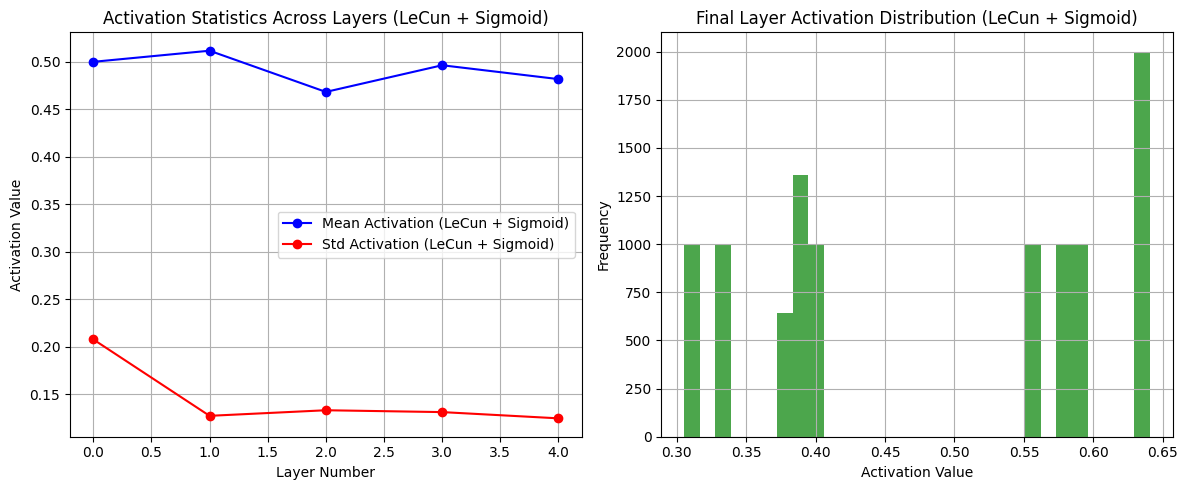

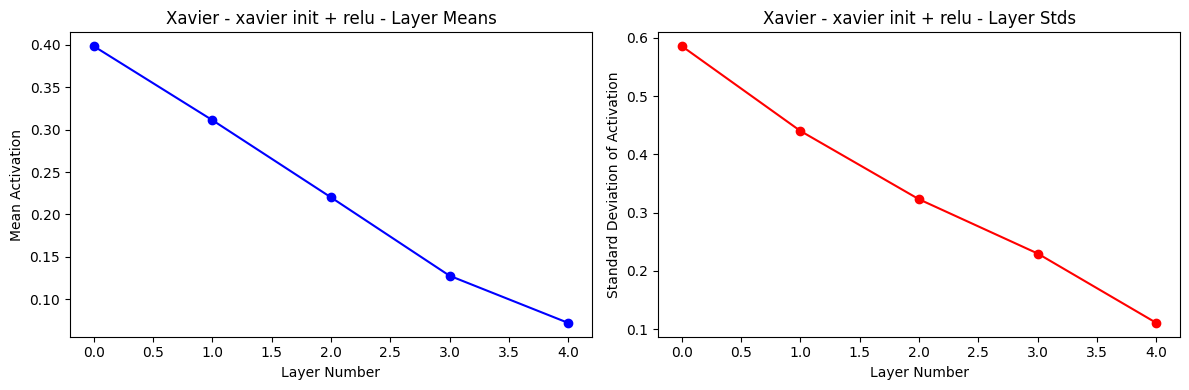

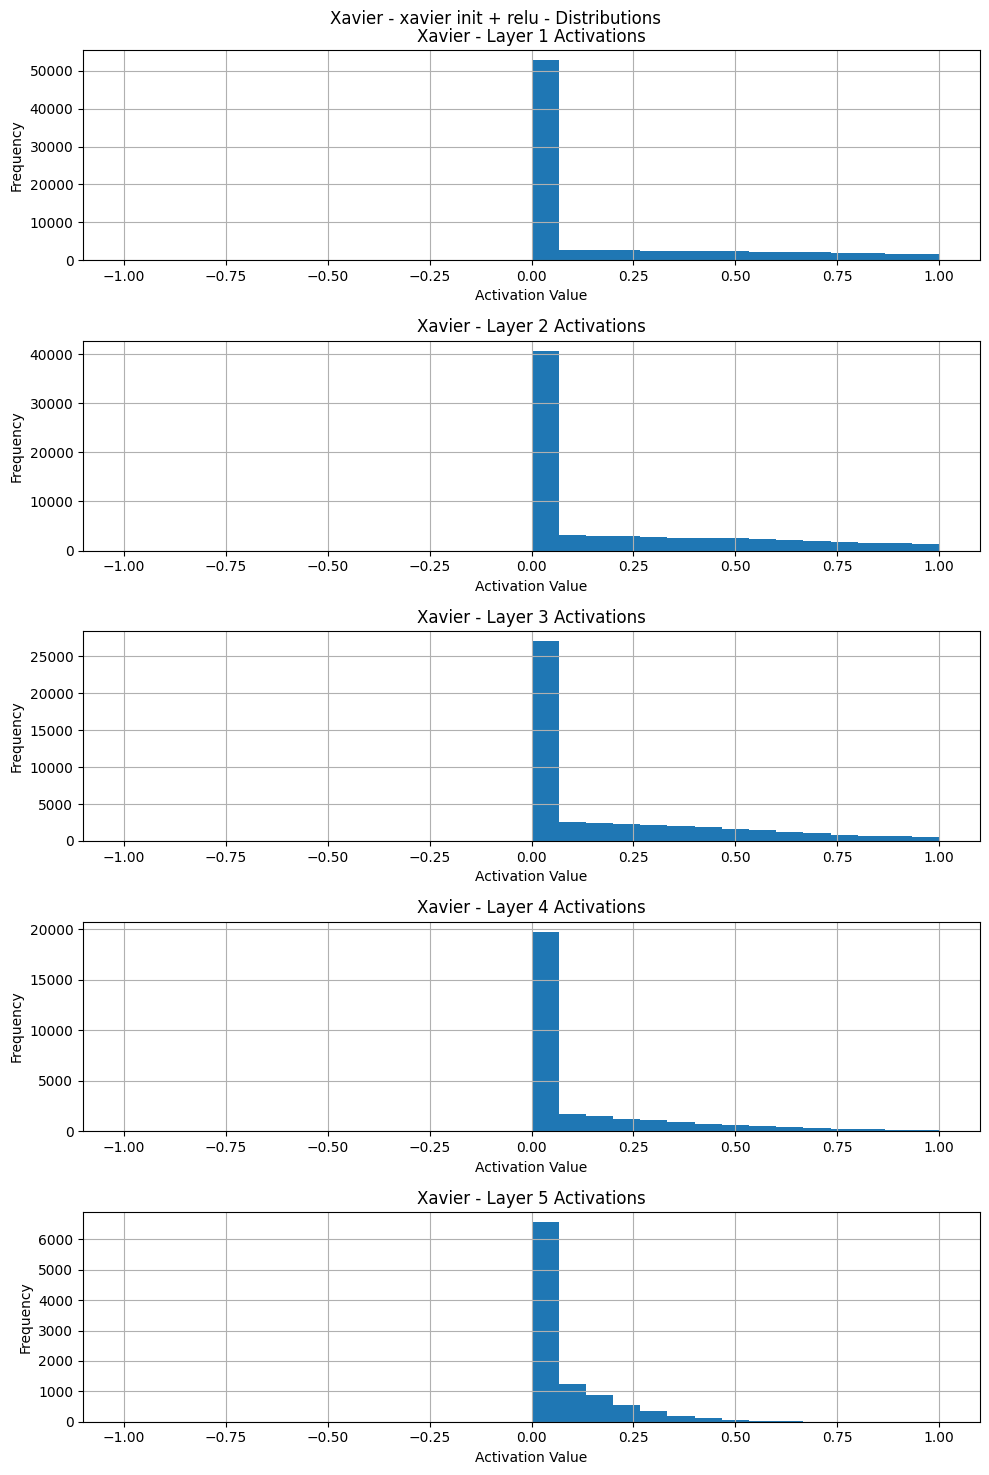

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# LeCun Initialization Function
def lecun_initialization(fan_in, fan_out):
    """
    LeCun initialization: weights scaled by sqrt(1/fan_in)
    Optimal for sigmoid-like activation functions
    """
    return np.random.randn(fan_in, fan_out) * np.sqrt(1.0 / fan_in)

# Sigmoid Activation Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Network Parameters
num_samples = 1000  # Number of input samples
input_dim = 100     # Input dimension
layer_sizes = [100, 80, 50, 30, 10]  # Layer architecture

# Initialize activations storage
activations_lecun_sigmoid = []

# Generate random input data
np.random.seed(42)
x = np.random.randn(num_samples, input_dim)

# Forward pass through network with LeCun and Sigmoid
x_lecun_sigmoid = x.copy()
for i, layer_size in enumerate(layer_sizes):
    # Initialize weights with LeCun initialization
    weights = lecun_initialization(x_lecun_sigmoid.shape[1], layer_size)

    # Linear transformation
    x_lecun_sigmoid = np.dot(x_lecun_sigmoid, weights)

    # Apply sigmoid activation
    x_lecun_sigmoid = sigmoid(x_lecun_sigmoid)
    activations_lecun_sigmoid.append(x_lecun_sigmoid.copy())

# -------------------
# Second Part of the Original Code (with Xavier and ReLU)
# -------------------

# Constants
D = 100   # Input size (number of features) - 맞춰서 수정
N = 1000  # Number of examples (samples)
hidden_layer_sizes_xavier = [100, 80, 50, 30, 10]  # 맞춰서 수정
nonlinearities = ['relu']  # Activation function

# Activation Functions
act_funcs = {
    'relu': lambda x: np.maximum(0, x),  # ReLU activation function
    'tanh': lambda x: np.tanh(x)  # Tanh activation function
}

# Weight Initialization Methods
init_methods = {
    'xavier': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) / np.sqrt(fan_in),  # Xavier initialization
}

# Experiment function to run the model and plot results
def run_and_plot(activation, init_type, input_data, layer_dims, title_prefix):
    np.random.seed(42)  # Set seed for reproducibility
    X = input_data.copy()
    Hs = {}  # Dictionary to store activations of each layer
    nonlin = act_funcs[activation]  # Select the activation function
    init_fn = init_methods[init_type]  # Select weight initialization method

    # Forward pass through each layer
    for i in range(len(layer_dims)):
        X = X if i == 0 else Hs[i-1]  # Use input for the first layer
        fan_in = X.shape[1]  # Number of input units
        fan_out = layer_dims[i]  # Number of neurons in the current layer
        W = init_fn(fan_in, fan_out)  # Initialize weights
        H = X @ W  # Matrix multiplication
        H = nonlin(H)  # Apply activation function
        Hs[i] = H  # Store activations

    # Compute mean and standard deviation of activations for each layer
    layer_means = [np.mean(H) for H in Hs.values()]
    layer_stds = [np.std(H) for H in Hs.values()]

    # Plot the mean and standard deviation for each layer
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(len(Hs)), layer_means, 'ob-')
    plt.xlabel('Layer Number')
    plt.ylabel('Mean Activation')
    plt.title(f'{title_prefix} - {init_type} init + {activation} - Layer Means')

    plt.subplot(1, 2, 2)
    plt.plot(range(len(Hs)), layer_stds, 'or-')
    plt.xlabel('Layer Number')
    plt.ylabel('Standard Deviation of Activation')
    plt.title(f'{title_prefix} - {init_type} init + {activation} - Layer Stds')
    plt.tight_layout()
    plt.show()

    # Plot histograms for activations in each layer
    plt.figure(figsize=(10, 15))
    for i, H in Hs.items():
        plt.subplot(len(Hs), 1, i + 1)
        plt.hist(H.ravel(), bins=30, range=(-1, 1))
        plt.title(f'{title_prefix} - Layer {i+1} Activations')
        plt.xlabel('Activation Value')
        plt.ylabel('Frequency')
        plt.grid(True)
    plt.suptitle(f'{title_prefix} - {init_type} init + {activation} - Distributions')
    plt.tight_layout()
    plt.show()

# -------------------
# Visualization of LeCun with Sigmoid
# -------------------
plt.figure(figsize=(12, 5))

# Plot mean and standard deviation across layers for LeCun + Sigmoid
plt.subplot(1, 2, 1)
layer_indices = range(len(layer_sizes))
means_lecun_sigmoid = [np.mean(a) for a in activations_lecun_sigmoid]
stds_lecun_sigmoid = [np.std(a) for a in activations_lecun_sigmoid]

plt.plot(layer_indices, means_lecun_sigmoid, 'bo-', label='Mean Activation (LeCun + Sigmoid)')
plt.plot(layer_indices, stds_lecun_sigmoid, 'ro-', label='Std Activation (LeCun + Sigmoid)')
plt.xlabel('Layer Number')
plt.ylabel('Activation Value')
plt.title('Activation Statistics Across Layers (LeCun + Sigmoid)')
plt.legend()
plt.grid(True)

# Plot histogram of final layer activations for LeCun + Sigmoid
plt.subplot(1, 2, 2)
plt.hist(activations_lecun_sigmoid[-1].ravel(), bins=30, color='green', alpha=0.7)
plt.title('Final Layer Activation Distribution (LeCun + Sigmoid)')
plt.xlabel('Activation Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

# -------------------
# Experiments with Xavier and ReLU (using the run_and_plot function)
# -------------------
run_and_plot('relu', 'xavier', np.random.randn(N, D), hidden_layer_sizes_xavier, 'Xavier')